In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [53]:
df=pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [8]:
df.shape[0]

4000

In [9]:
df.shape[1]

28

In [10]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [11]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [12]:
missing = df.isnull().sum()

print(missing[missing > 0])

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


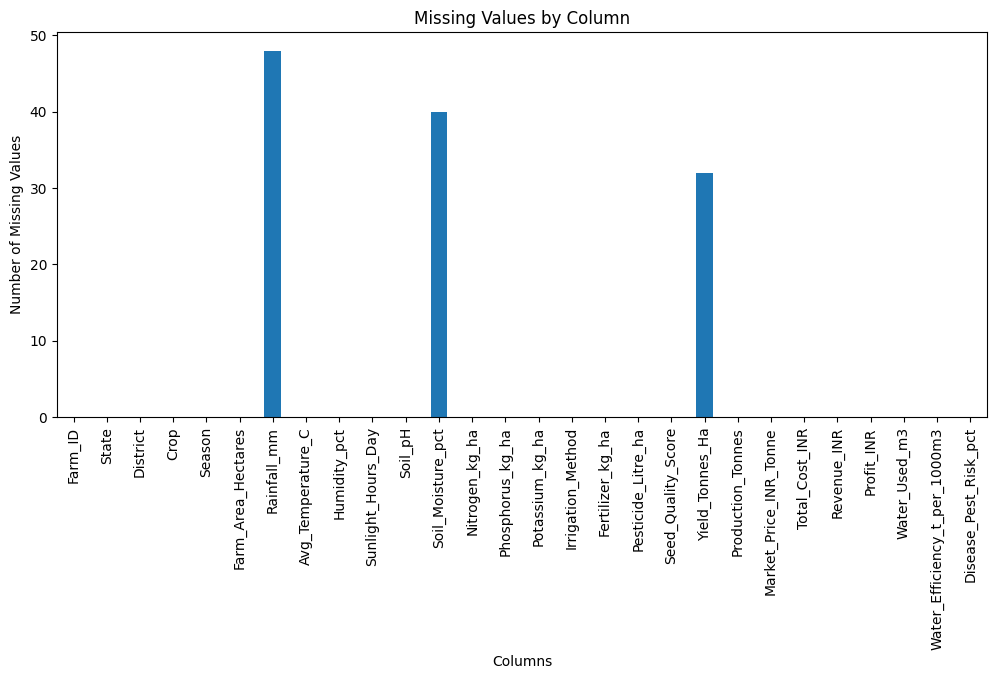

In [13]:
plt.figure(figsize=(12, 5))

df.isnull().sum().plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.show()

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
df = df.drop_duplicates()

In [16]:
print(df['Season'].unique())
print(df['Season'].value_counts())

['Kharif' 'Rabi' 'Zaid']
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [17]:
season_performance = df.groupby('Season')[
    ['Yield_Tonnes_Ha',
     'Production_Tonnes',
     'Revenue_INR',
     'Profit_INR',
     'Total_Cost_INR']
].mean()

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Total_Cost_INR
Season,,,,,
Kharif,5.643973,46.311192,710719.055649,178914.647555,531804.408094
Rabi,5.080498,41.486712,601526.048556,87689.470191,513836.578365
Zaid,4.665942,38.886111,519171.904040,-24804.824916,543976.728956


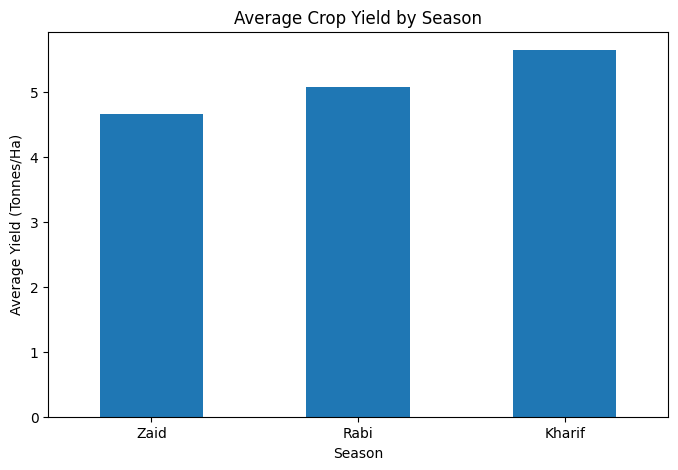

In [18]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values()

plt.figure(figsize=(8, 5))

season_yield.plot(kind='bar')

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)

plt.show()

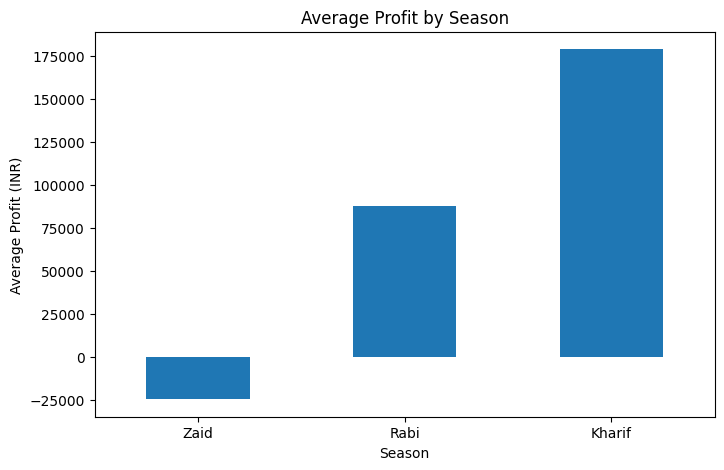

In [19]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values()

plt.figure(figsize=(8, 5))

season_profit.plot(kind='bar')

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)

plt.show()

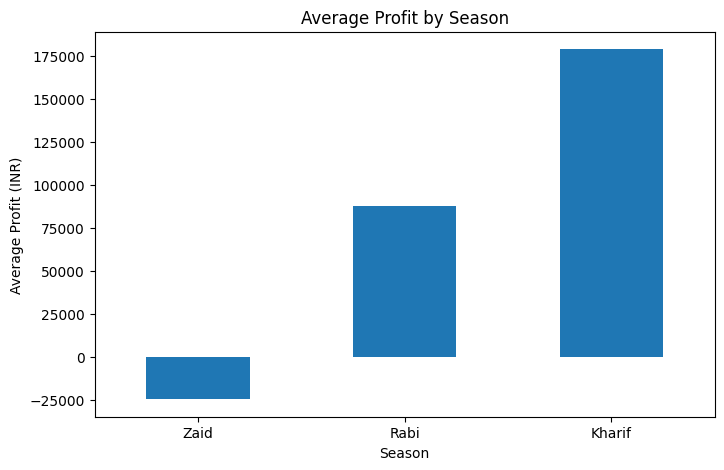

In [20]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values()

plt.figure(figsize=(8, 5))

season_profit.plot(kind='bar')

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)

plt.show()

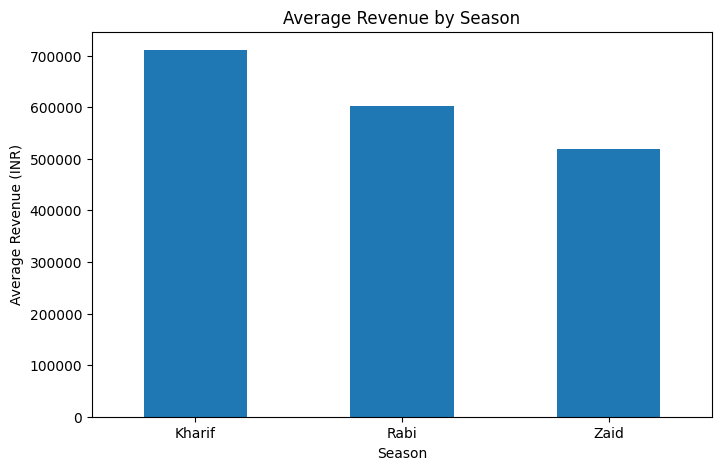

In [21]:
season_revenue = df.groupby('Season')['Revenue_INR'].mean()

plt.figure(figsize=(8, 5))

season_revenue.plot(kind='bar')

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=0)

plt.show()

In [22]:
environmental = df.groupby('Season')[
    ['Rainfall_mm',
     'Avg_Temperature_C',
     'Humidity_pct',
     'Sunlight_Hours_Day',
     'Soil_Moisture_pct']
].mean()

environmental

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.084205,28.454019,71.812591,6.793367,31.198410
Rabi,436.000124,23.489183,57.893178,7.589797,24.050620
Zaid,299.421784,31.042088,52.012121,8.178788,19.170085


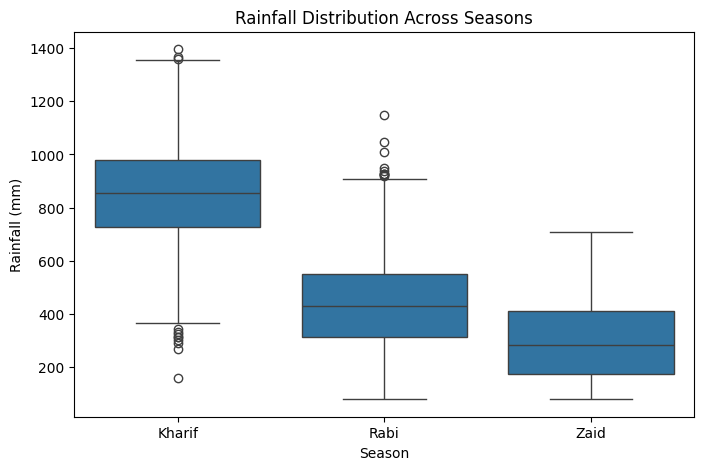

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Season', y='Rainfall_mm')

plt.title("Rainfall Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

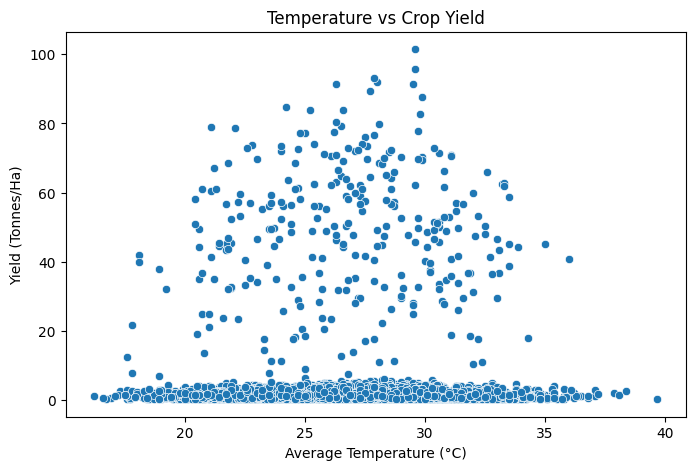

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha'
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

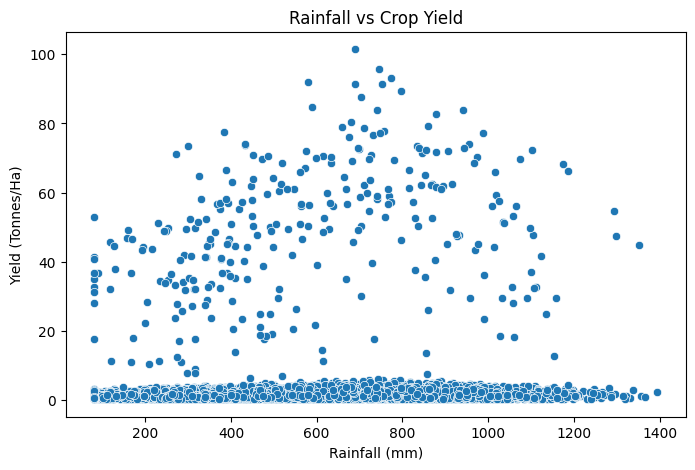

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

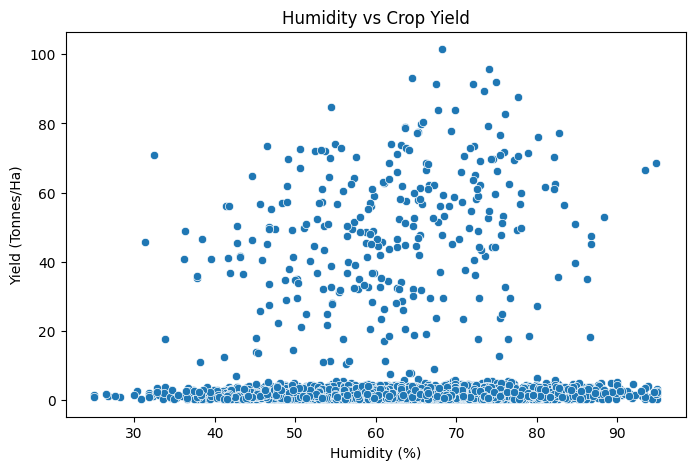

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Humidity_pct',
    y='Yield_Tonnes_Ha'
)

plt.title("Humidity vs Crop Yield")
plt.xlabel("Humidity (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

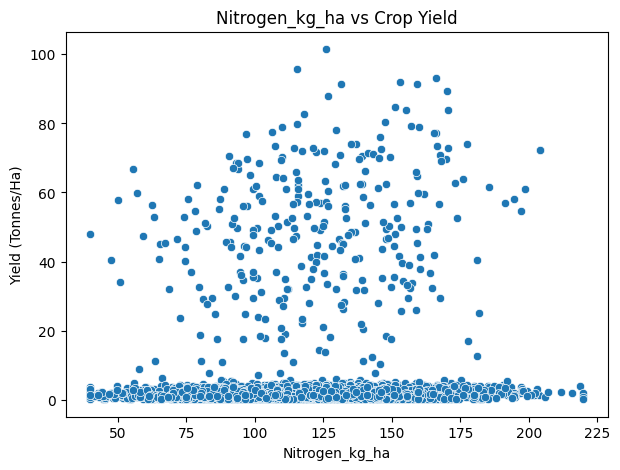

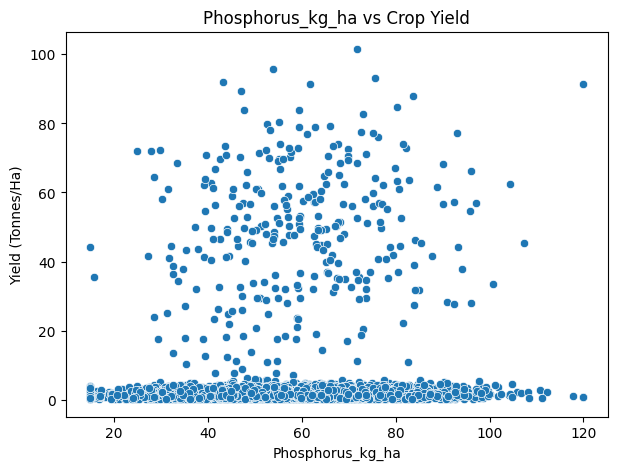

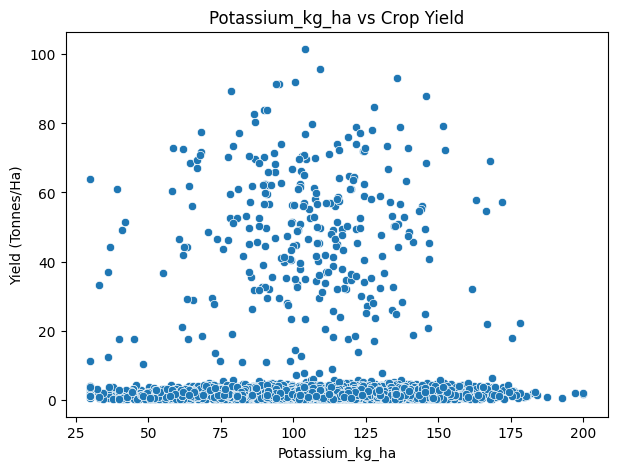

In [27]:
nutrients = [
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha'
]

for column in nutrients:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x=column,
        y='Yield_Tonnes_Ha'
    )

    plt.title(f"{column} vs Crop Yield")
    plt.xlabel(column)
    plt.ylabel("Yield (Tonnes/Ha)")

    plt.show()

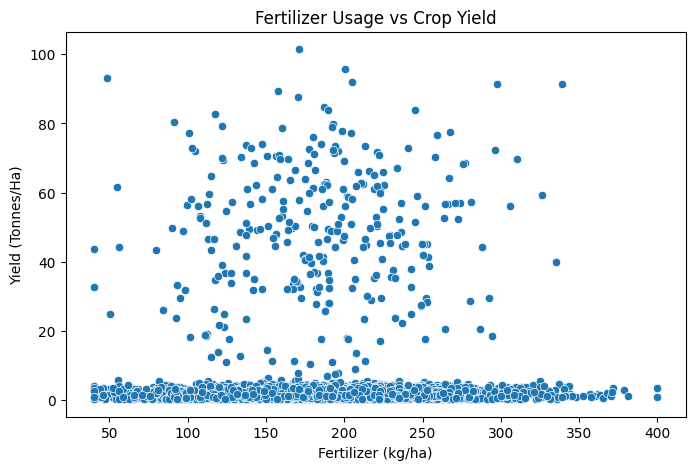

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha'
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [29]:
irrigation_analysis = df.groupby('Irrigation_Method')[
    ['Yield_Tonnes_Ha',
     'Water_Used_m3',
     'Water_Efficiency_t_per_1000m3',
     'Profit_INR']
].mean()

irrigation_analysis

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.620662,5918.747541,6.267129,219625.997814
Flood,4.897724,8026.472519,3.438853,73354.022901
Rainfed,4.613182,3549.554275,7.563784,79050.365034
Sprinkler,5.188819,6208.258856,4.669805,91121.079019


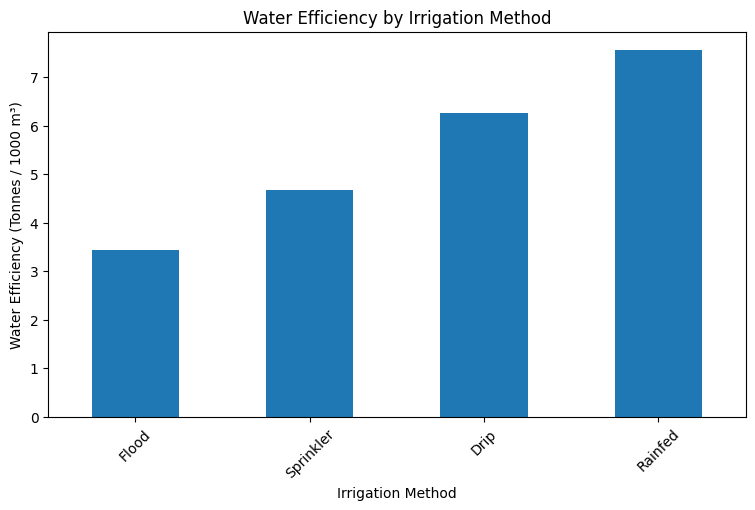

In [30]:
plt.figure(figsize=(9, 5))

efficiency = df.groupby(
    'Irrigation_Method'
)['Water_Efficiency_t_per_1000m3'].mean().sort_values()

efficiency.plot(kind='bar')

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes / 1000 m³)")
plt.xticks(rotation=45)

plt.show()

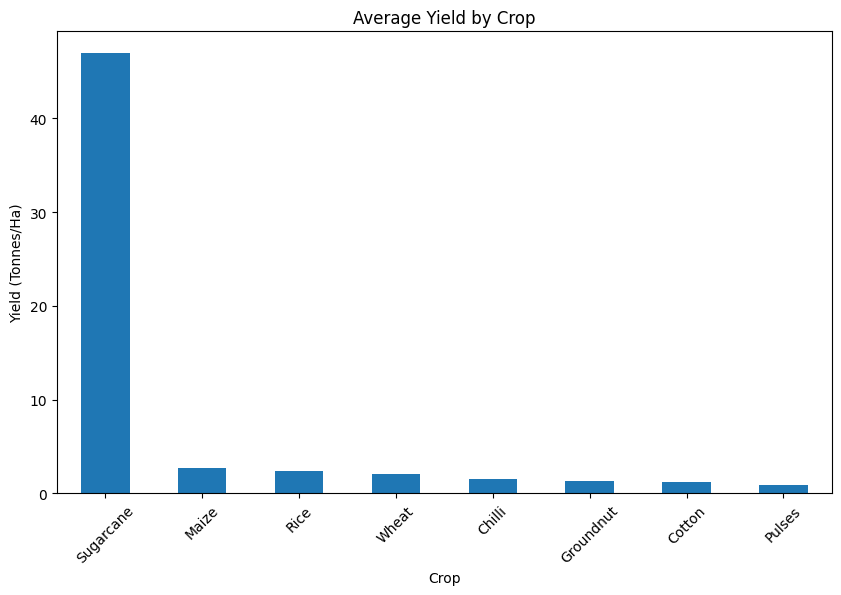

In [31]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

crop_yield.plot(kind='bar')

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

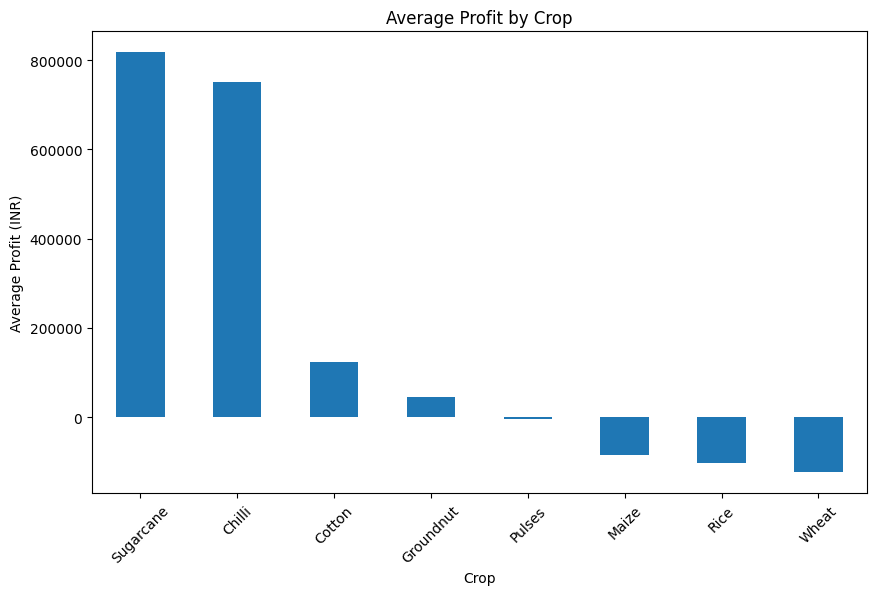

In [32]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

crop_profit.plot(kind='bar')

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

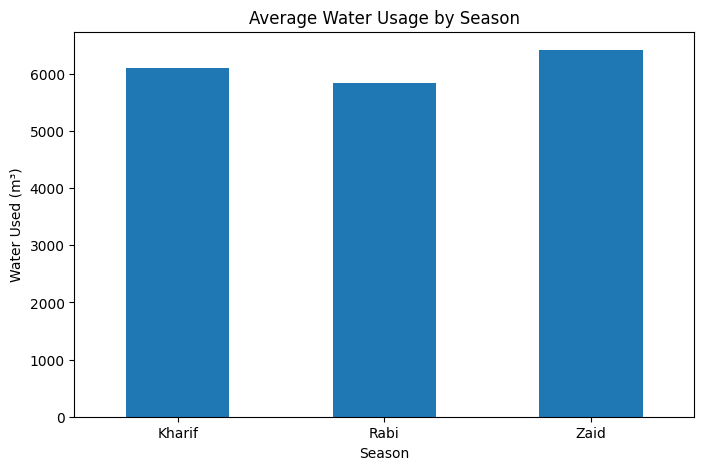

In [33]:
water_season = df.groupby('Season')['Water_Used_m3'].mean()

plt.figure(figsize=(8, 5))

water_season.plot(kind='bar')

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=0)

plt.show()

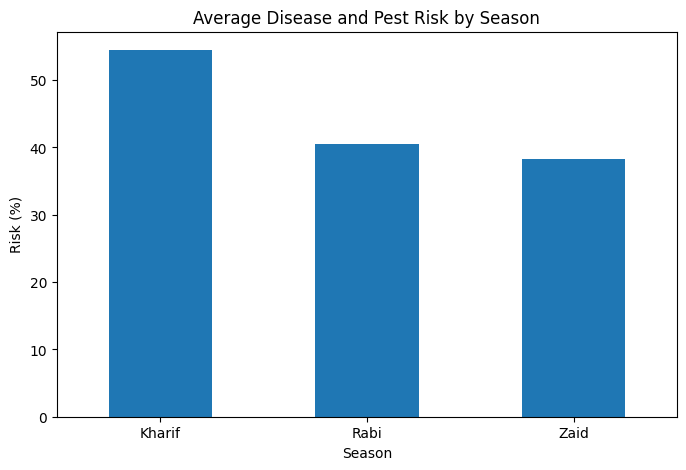

In [34]:
risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()

plt.figure(figsize=(8, 5))

risk.plot(kind='bar')

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)

plt.show()

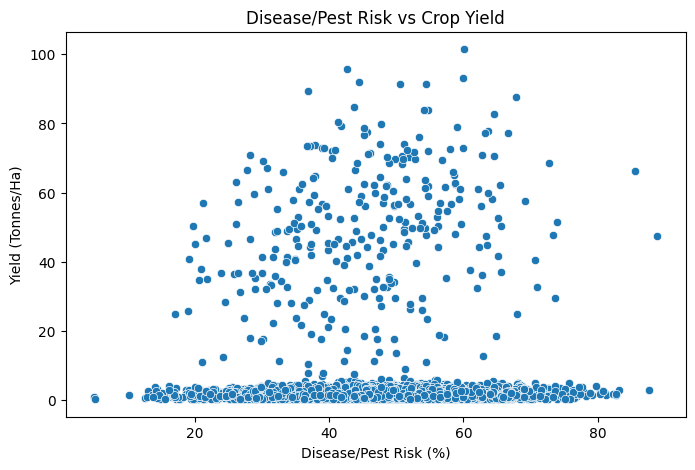

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha'
)

plt.title("Disease/Pest Risk vs Crop Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

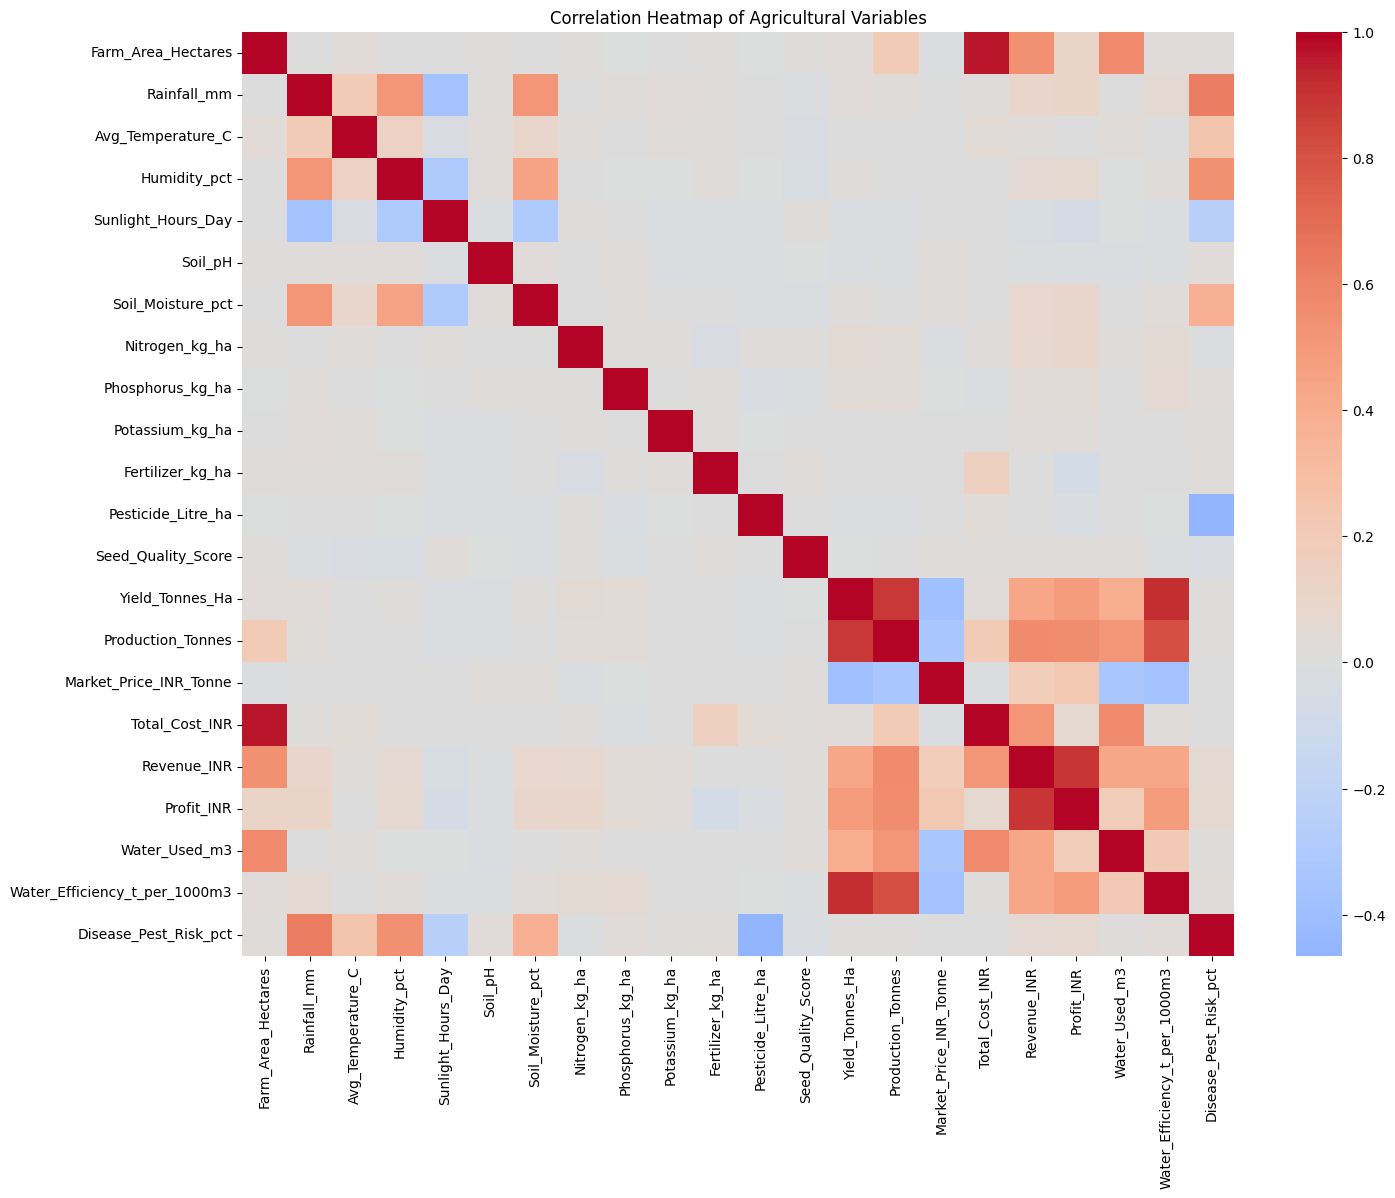

In [36]:
numeric_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=False,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap of Agricultural Variables")

plt.show()

In [37]:
yield_corr = correlation['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

print(yield_corr)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Farm_Area_Hectares               0.030188
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64


In [38]:
profit_corr = correlation['Profit_INR'].sort_values(
    ascending=False
)

print(profit_corr)

Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Yield_Tonnes_Ha                  0.489822
Water_Efficiency_t_per_1000m3    0.489487
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.108104
Soil_Moisture_pct                0.091757
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


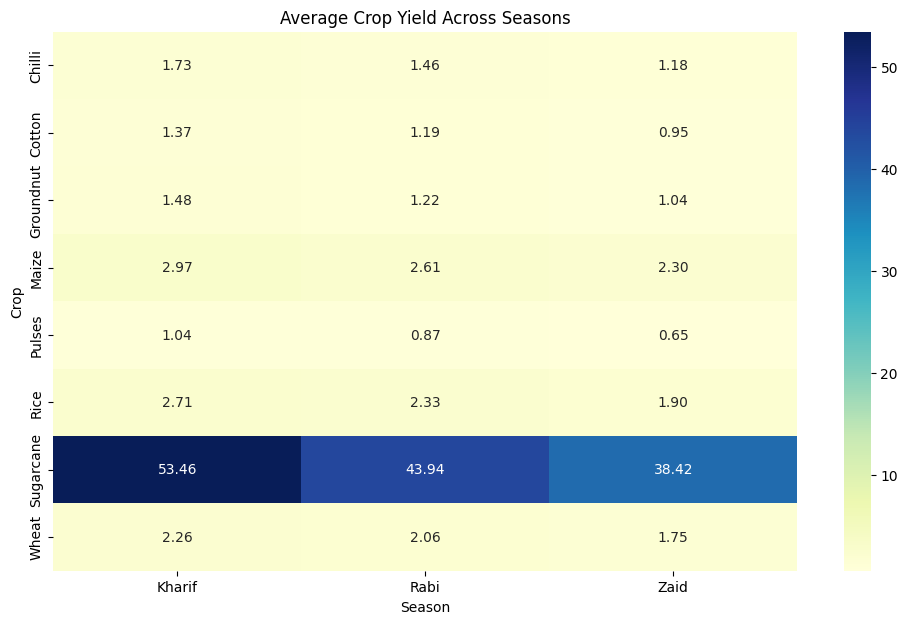

In [39]:
season_crop = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    season_crop,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [40]:
state_season = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.693431,3.488069,4.480238
Gujarat,6.338416,5.517245,4.101970
Karnataka,6.523689,4.609655,6.623243
Madhya Pradesh,6.004133,3.800000,5.539194
Maharashtra,5.447014,5.501927,2.285352
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.555539,4.097746
Telangana,5.568798,4.831649,4.278333


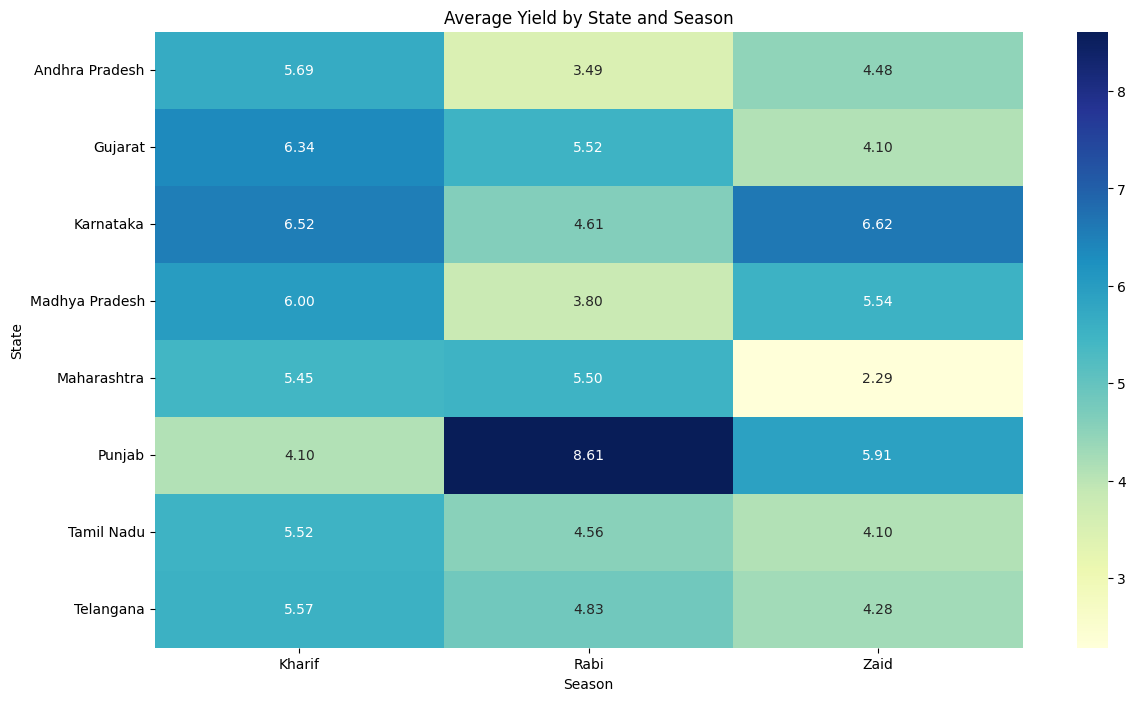

In [41]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    state_season,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.show()

In [42]:
from scipy.stats import f_oneway

season_groups = [
    group['Yield_Tonnes_Ha'].values
    for name, group in df.groupby('Season')
]

f_stat, p_value = f_oneway(*season_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: nan
P-value: nan


In [43]:
if p_value < 0.05:
    print("There is a statistically significant difference in yield between seasons.")
else:
    print("There is no statistically significant difference in yield between seasons.")

There is no statistically significant difference in yield between seasons.


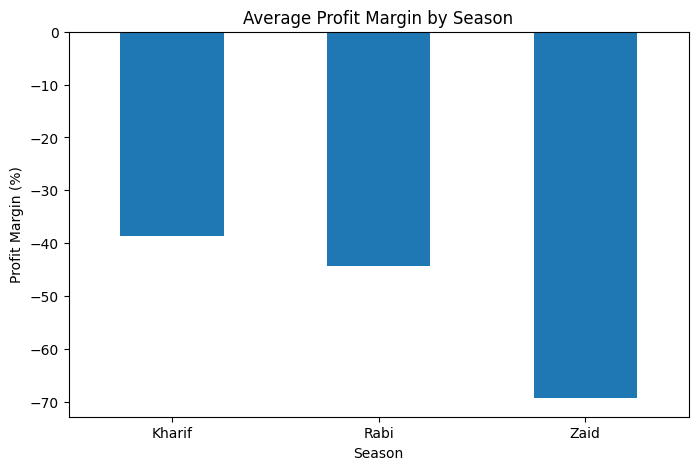

In [44]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

margin = df.groupby('Season')['Profit_Margin_pct'].mean()

plt.figure(figsize=(8, 5))

margin.plot(kind='bar')

plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)

plt.show()

In [45]:
df['Cost_per_Tonne'] = (
    df['Total_Cost_INR'] / df['Production_Tonnes']
)

df[['Total_Cost_INR', 'Production_Tonnes', 'Cost_per_Tonne']].head()

,Total_Cost_INR,Production_Tonnes,Cost_per_Tonne
0,42662,1.30,32816.923077
1,492351,1.96,251199.489796
2,315210,2.53,124588.932806
3,296444,8.28,35802.415459
4,337959,9.30,36339.677419


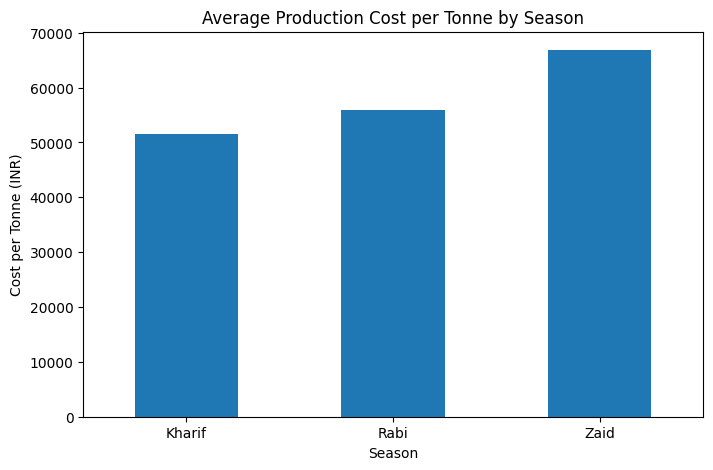

In [46]:
cost_season = df.groupby('Season')['Cost_per_Tonne'].mean()

plt.figure(figsize=(8, 5))

cost_season.plot(kind='bar')

plt.title("Average Production Cost per Tonne by Season")
plt.xlabel("Season")
plt.ylabel("Cost per Tonne (INR)")
plt.xticks(rotation=0)

plt.show()

In [47]:
top_crops = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
)

top_crops

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
Crop,,,
Sugarcane,46.938746,817187.986885,30.477672
Chilli,1.540344,750878.342233,2.947709
Cotton,1.225734,124546.915354,1.938016
Groundnut,1.317924,44858.120283,3.154795
Pulses,0.918198,-4238.052419,2.896504
Maize,2.717130,-83978.326679,5.602995
Rice,2.439413,-102213.504348,1.946112
Wheat,2.109216,-123398.337134,4.628393


In [48]:
top_farms = df.sort_values(
    'Profit_INR',
    ascending=False
).head(10)

top_farms[
    ['Farm_ID',
     'State',
     'District',
     'Crop',
     'Season',
     'Yield_Tonnes_Ha',
     'Revenue_INR',
     'Profit_INR']
]

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,3.90,5057448,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,2.92,5080900,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,4485260,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3.01,4522464,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3.09,4825365,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,4350998,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,4428460,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,4108301,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3.02,4055609,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,2.53,3987664,3159447


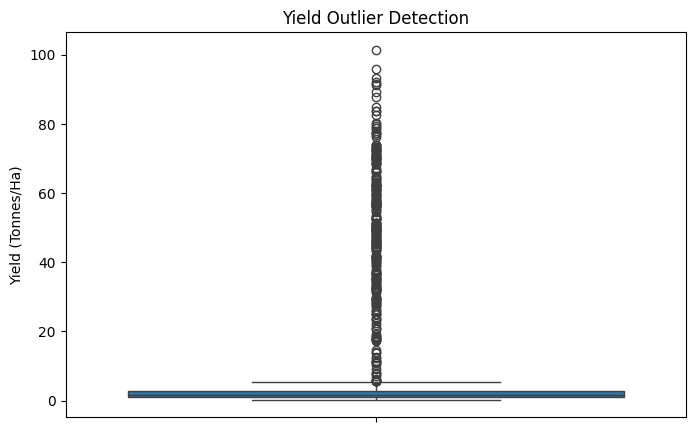

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y='Yield_Tonnes_Ha'
)

plt.title("Yield Outlier Detection")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [50]:
final_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

final_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.64,46.31,710719.06,178914.65,531804.41,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,87689.47,513836.58,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,-24804.82,543976.73,6419.89,4.41,38.22


In [51]:
best_yield_season = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .idxmax()
)

best_profit_season = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .idxmax()
)

best_efficiency_season = (
    df.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .idxmax()
)

print("Best Season by Yield:", best_yield_season)
print("Best Season by Profit:", best_profit_season)
print("Best Season by Water Efficiency:", best_efficiency_season)

Best Season by Yield: Kharif
Best Season by Profit: Kharif
Best Season by Water Efficiency: Kharif


In [52]:
print("SEASONAL AGRICULTURE PERFORMANCE SUMMARY")
print("-" * 50)

print("Highest Yield Season:",
      df.groupby('Season')['Yield_Tonnes_Ha'].mean().idxmax())

print("Highest Profit Season:",
      df.groupby('Season')['Profit_INR'].mean().idxmax())

print("Highest Revenue Season:",
      df.groupby('Season')['Revenue_INR'].mean().idxmax())

print("Most Water-Efficient Season:",
      df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().idxmax())

print("Lowest Disease/Pest Risk Season:",
      df.groupby('Season')['Disease_Pest_Risk_pct'].mean().idxmin())

SEASONAL AGRICULTURE PERFORMANCE SUMMARY
--------------------------------------------------
Highest Yield Season: Kharif
Highest Profit Season: Kharif
Highest Revenue Season: Kharif
Most Water-Efficient Season: Kharif
Lowest Disease/Pest Risk Season: Zaid
